# 05 — Isolation Forest and Validation

**What this notebook establishes:** the leakage-safe feature set, the Isolation Forest / LOF anomaly scores, and the full Stage 7 validation — average precision, precision@k, bootstrap confidence intervals, and the anomaly-type x detection-method matrix.

**Estimated runtime:** ~30 seconds

All logic lives in `src/`; this notebook only calls into it and displays results (plan/00_MASTER_PLAN.md sec 5).

## 1. Features

`src/models.py` (Stage 6) builds a leakage-safe feature matrix — `amount`, `quantity`, `price`, `hour`, `day_of_week`, and per-customer aggregates (`cust_txn_count`, `cust_amount_mean`, `cust_amount_std`) plus `rule_flag_count` — explicitly excluding `is_synthetic_anomaly`, `anomaly_type` and `txn_id` (the Leakage Firewall, `plan/00_MASTER_PLAN.md` sec 6).

In [1]:
import json
import pandas as pd
from pathlib import Path
ROOT = Path('..').resolve()
model_summary = json.loads((ROOT/'reports/metrics/model_summary.json').read_text())
print('feature columns:', model_summary['feature_columns'])
print('rows scored:', model_summary['total_rows'])

feature columns: ['amount', 'quantity', 'price', 'hour', 'day_of_week', 'cust_txn_count', 'cust_amount_mean', 'cust_amount_std']
rows scored: 50000


## 2. Validation — the project's central artefact

Every method is joined on `txn_id` against the ground truth (`src.validate.load_evaluation_frame`) and scored with ranking metrics that are honest about class imbalance: Average Precision leads, not accuracy.

In [2]:
mm = json.loads((ROOT/'reports/metrics/model_metrics.json').read_text())
print('population:', mm['population'])
pd.DataFrame(mm['models']).T[['average_precision','roc_auc','precision','recall','f1']]

population: {'n_total': 50000, 'n_injected': 802, 'anomaly_rate': 0.01604}


,average_precision,roc_auc,precision,recall,f1
benford_any,NaN,NaN,0.016014,0.927681,0.031485
rules_any,NaN,NaN,0.054592,0.639651,0.100598
iforest,0.13605,0.713953,0.316,0.295511,0.305412
lof,0.083485,0.629603,0.150667,0.140898,0.145619
composite,0.181662,0.733958,0.305333,0.285536,0.295103


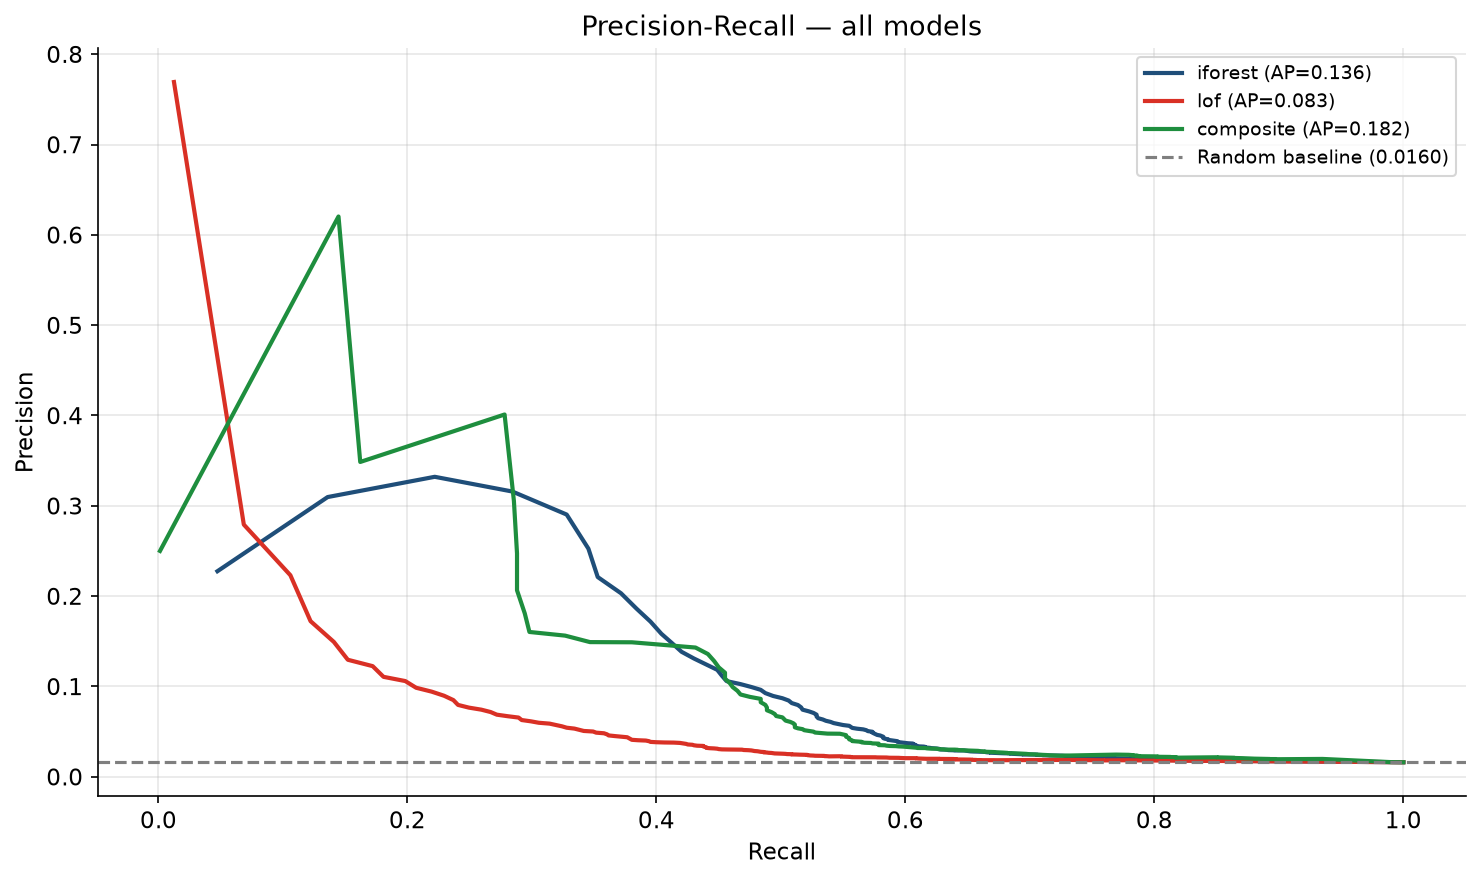

In [3]:
from IPython.display import Image
Image(filename=str(ROOT/'reports/figures/pr_curve.png'))

## 3. The anomaly-type x detection-method matrix

In [4]:
matrix = pd.read_csv(ROOT/'data/dashboard/method_comparison.csv')
matrix.pivot(index='anomaly_type', columns='method', values='pct_caught')

method,benford_any,composite,iforest,lof,rules_any
anomaly_type,,,,,
ALL_INJECTED,92.77,28.55,29.55,14.09,63.97
REAL_ROWS,92.92,1.06,1.04,1.29,18.06
digit_fabrication,89.19,0.00,0.90,17.12,46.85
duplicate,92.62,3.36,2.68,4.03,27.52
extreme_outlier,93.70,38.58,33.86,31.50,86.61
round_number,95.28,70.08,71.65,13.39,100.00
threshold_avoidance,93.08,53.46,61.01,18.87,100.00
timing,92.25,0.78,0.78,0.78,18.60


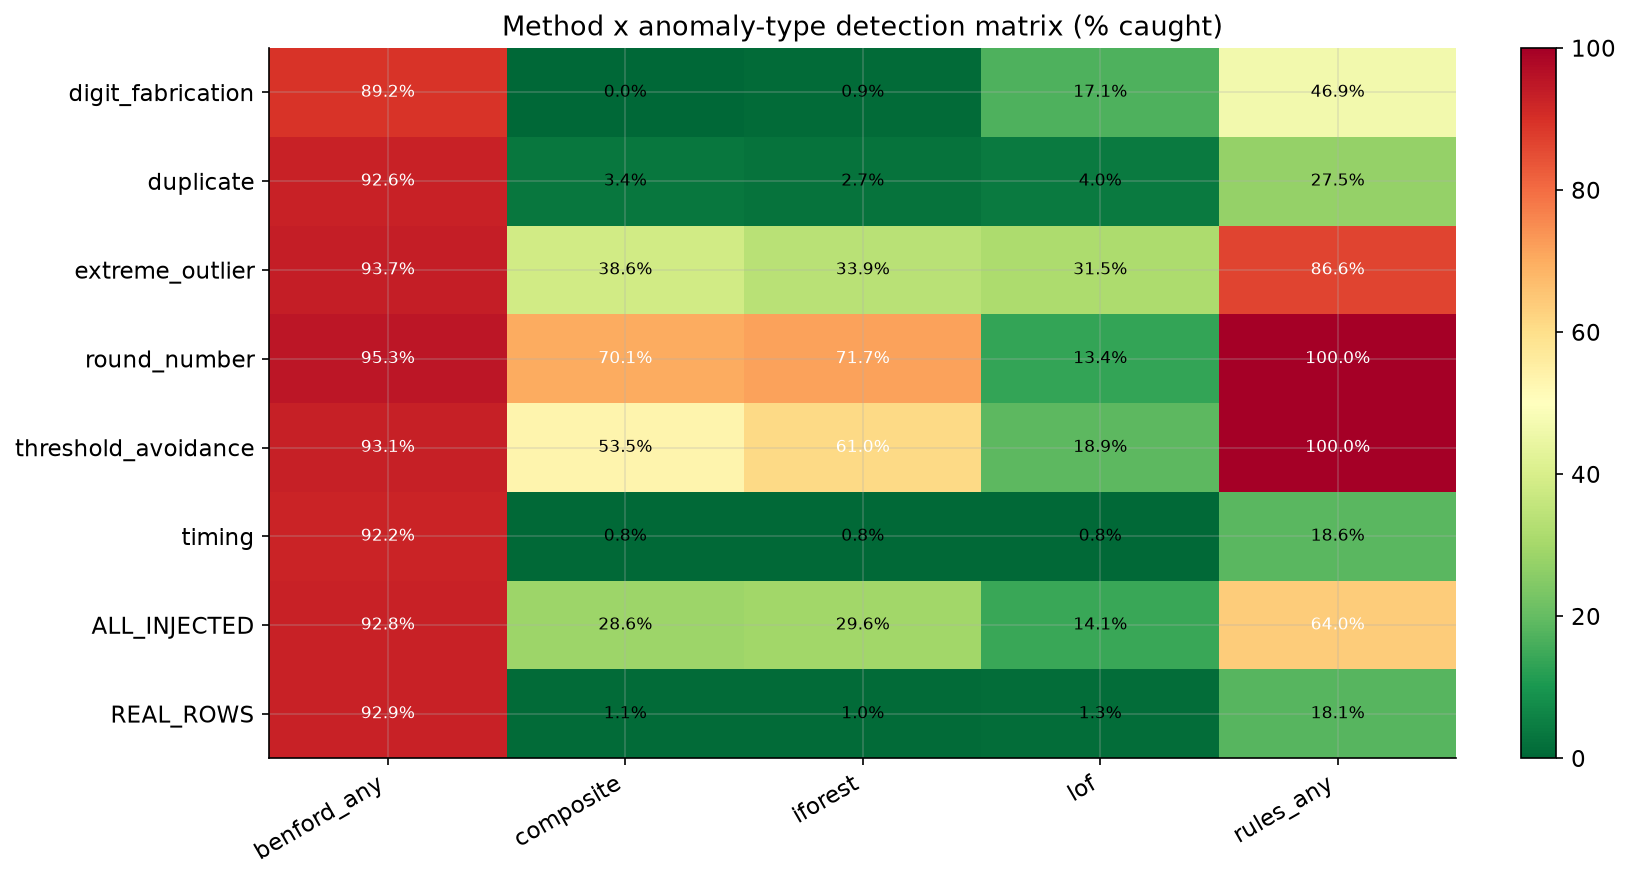

In [5]:
Image(filename=str(ROOT/'reports/figures/method_comparison_heatmap.png'))

**Honest finding** (see `DECISIONS.md` D-0004): in this run, rule-based checks catch every injected anomaly type at a higher rate than Isolation Forest at a matched 1.5% alert budget — the plan's template expectation that IF would uniquely dominate `extreme_outlier` did not hold here. The composite score still adds ranking value: its Average Precision (0.182) beats every individual method.